In [9]:
# ============================================================
# STEP 1: Generate Sample Binary Dataset (SOLUTION)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create synthetic binary classification data
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.7, 0.3],      # Class imbalance
    random_state=42
)

print("Dataset Shape:", X.shape)
print("Class Distribution:", np.bincount(y))
#Student's Task

#Make Dataframe


#Print first 5 rows
print("\nFirst 5 rows:")

Dataset Shape: (2000, 10)
Class Distribution: [1396  604]

First 5 rows:
   Feature_0  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  \
0  -0.527985   2.502247   0.695293  -1.795216  -1.116564  -1.533083   
1  -0.969457  -0.027843   0.491814  -0.904605   0.095751   1.047343   
2  -0.233425  -1.991787  -0.457817  -0.407070  -2.221362  -2.598014   
3  -1.746842   1.005994  -1.276618  -2.529162  -1.537575  -2.303886   
4  -1.297131  -1.451861   1.791782  -0.512722  -0.622481  -1.066218   

   Feature_6  Feature_7  Feature_8  Feature_9  Target  
0  -2.463545   1.197423  -1.900653   3.487929       0  
1  -0.838283  -0.857172  -0.848319   0.039613       0  
2   0.857989  -0.579129  -1.251154   0.165376       0  
3  -0.133311  -0.748383   0.509019   2.254463       0  
4  -1.250867  -0.000132  -0.928541   0.423256       0  


In [10]:
# ============================================================
# STEP 2: Split Data into Training and Testing Sets (SOLUTION)
# ============================================================

#Student's Task
#Split the Data in Training and Testing Sets

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1500, 10)
Test set size: (500, 10)


In [11]:
# ============================================================
# STEP 3: Create Decision Tree using Entropy (SOLUTION)
# ============================================================
#Student's Task: Make a Decision Tree Classifier(write inside parantheses)
model = DecisionTreeClassifier(
    
)

print("Model Parameters:")
print(model.get_params())

Model Parameters:
{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [12]:
# ============================================================
# STEP 4: Train the Model (SOLUTION)
# ============================================================

model.fit(X_train, y_train)

print("Model training completed!")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model training completed!
Tree depth: 5
Number of leaves: 19


In [13]:
# ============================================================
# STEP 5: Make Predictions (SOLUTION)
# ============================================================

#Student's Task: Calculate the predictions and probabilities
print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_prob[:10])

First 10 Predictions: [1 1 0 1 0 1 1 1 1 0]


In [14]:
# ============================================================
# STEP 6: Evaluate the Model (SOLUTION)
# ============================================================

print("\n" + "="*55)
print("     BINARY CLASSIFICATION (Entropy) - RESULTS")
print("="*55)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


     BINARY CLASSIFICATION (Entropy) - RESULTS

Accuracy: 0.8780

Confusion Matrix:
[[306  43]
 [ 18 133]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.94      0.88      0.91       349
     Class 1       0.76      0.88      0.81       151

    accuracy                           0.88       500
   macro avg       0.85      0.88      0.86       500
weighted avg       0.89      0.88      0.88       500




Top Feature Importances (Entropy-based):
     Feature  Importance
6  Feature_6    0.452328
4  Feature_4    0.286793
5  Feature_5    0.098240
8  Feature_8    0.059598
0  Feature_0    0.049511
1  Feature_1    0.027443
3  Feature_3    0.011892
2  Feature_2    0.007761
7  Feature_7    0.006435
9  Feature_9    0.000000


C:\Users\vvikr\AppData\Local\Temp\ipykernel_24424\3161416828.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


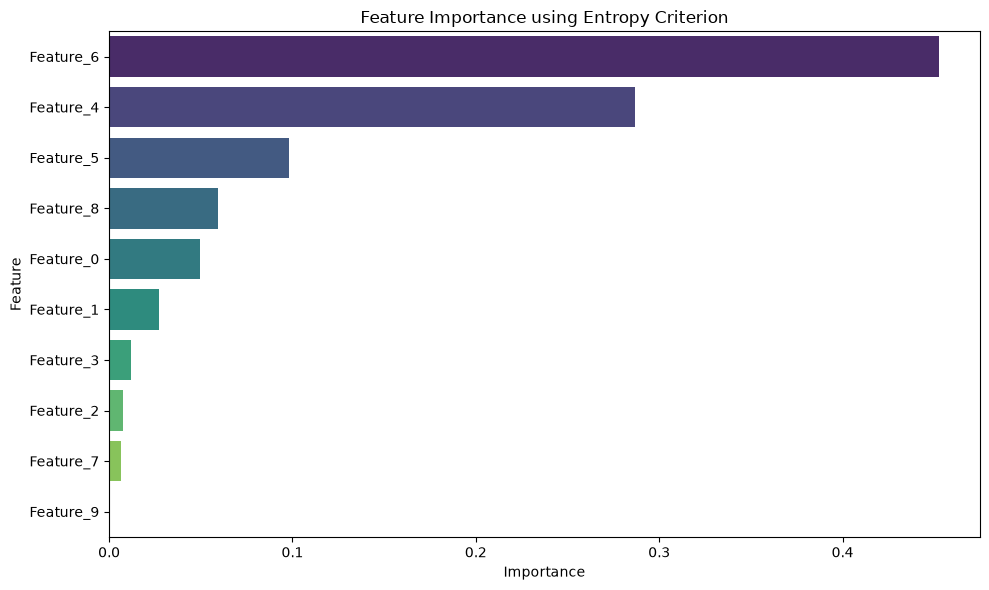

In [15]:
# ============================================================
# STEP 7: Feature Importance (SOLUTION)
# ============================================================

feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Feature Importances (Entropy-based):")
print(importance_df.head(10))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance using Entropy Criterion')
plt.tight_layout()
plt.show()

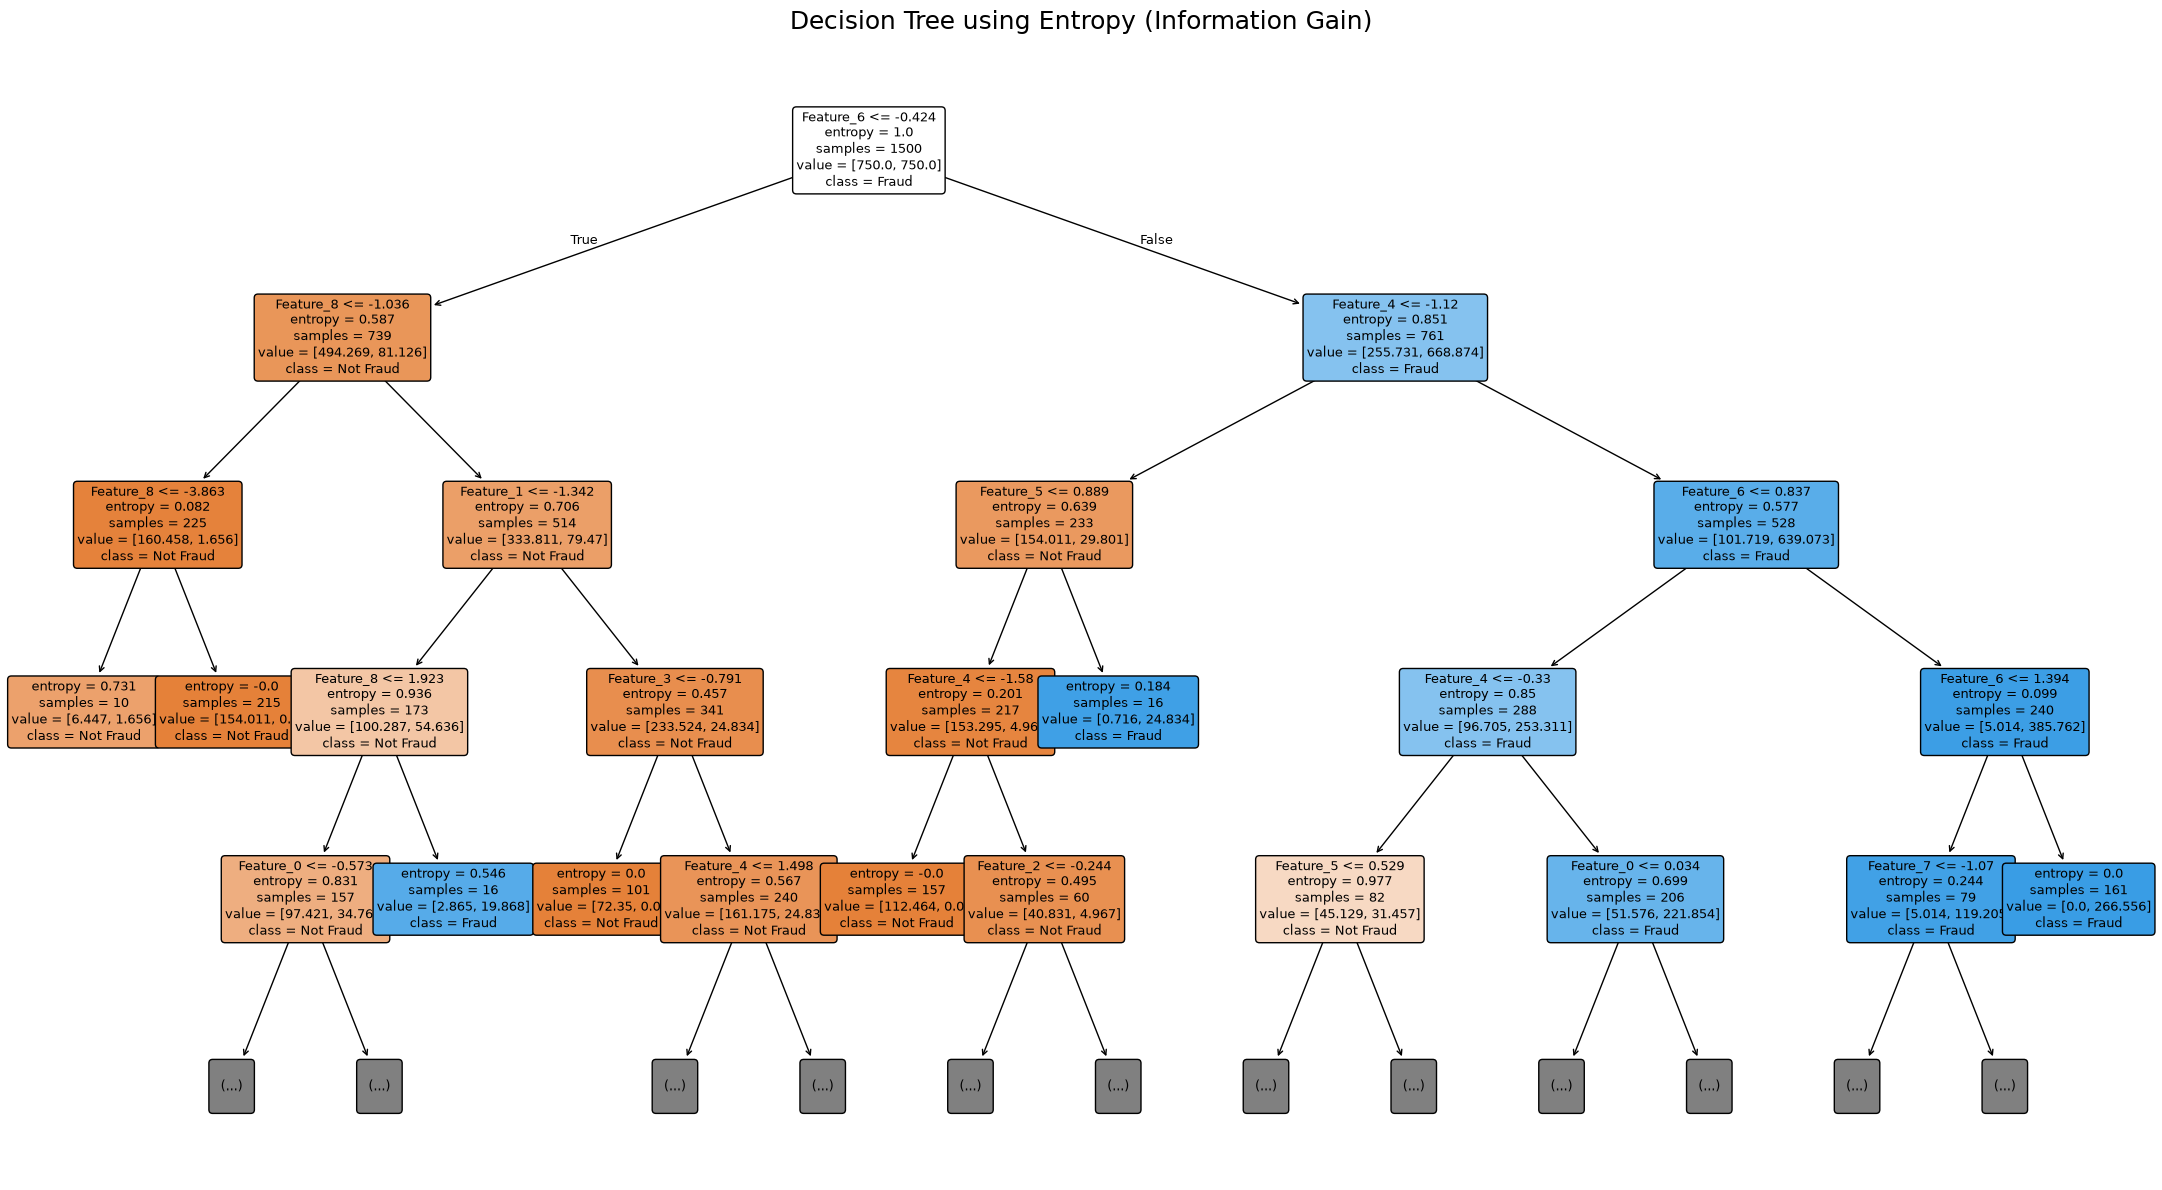

In [16]:
# ============================================================
# STEP 8: Decision Tree Visualization
# ============================================================

plt.figure(figsize=(22, 12))

plot_tree(
    model,
    feature_names=[f'Feature_{i}' for i in range(X.shape[1])],
    class_names=['Not Fraud', 'Fraud'],   # Change according to your problem
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4                          # You can increase this if tree is small
)

plt.title("Decision Tree using Entropy (Information Gain)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()